In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import gzip
import scipy.sparse as sp
from collections import defaultdict
import sklearn
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    adjusted_mutual_info_score,
    fowlkes_mallows_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
    confusion_matrix
)
from umap import UMAP
import seaborn as sns
import anndata as ad
from process import SpaHDSRL
import warnings
warnings.filterwarnings('ignore')
random_seed = 20

In [ ]:
adata1 = sc.read_h5ad(r".\tutorial2\simulated_1.h5ad")
adata2 = sc.read_h5ad(r".\tutorial2\simulated_2.h5ad")

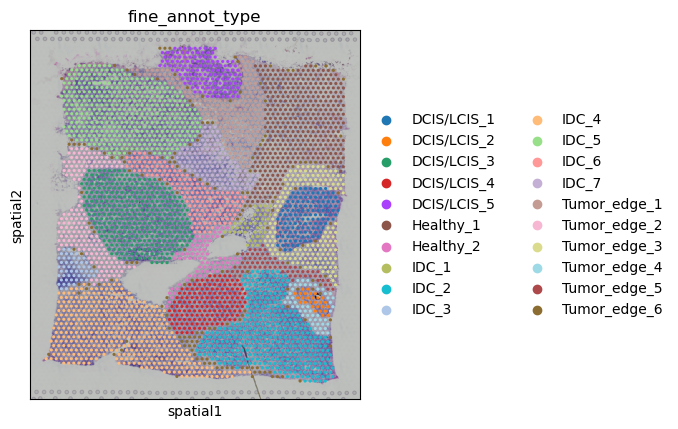

In [4]:
sc.pl.spatial(
    adata1,
    color="fine_annot_type",
    spot_size=170,
    alpha_img=1,
)

In [ ]:
SpaHDSRL_result = SpaHDSRL(adata1=adata1,adata2=adata2)
SpaHDSRL_result.preprocessing_data(do_norm=True, n_neighbors = 10)
SpaHDSRL_result.train(spatial_regularization_strength=0.008, z_dim=50, 
         lr=1e-3, wnn_epoch = 500, total_epoch=300, max_patience_bef=10, max_patience_aft=30, min_stop=200, 
         random_seed=random_seed, gpu=0, regularization_acceleration=True, edge_subset_sz=1000000, k_neighbors=10, gamma=0.05)
df_embedding = pd.DataFrame(SpaHDSRL_result.embedding)

Epoch 1/300, Loss: 1.3893464803695679
Epoch 11/300, Loss: 1.304611325263977
Epoch 21/300, Loss: 1.394795298576355
Epoch 31/300, Loss: 1.106728196144104
Epoch 41/300, Loss: 0.9901718497276306
Epoch 51/300, Loss: 0.8139193058013916
Epoch 61/300, Loss: 1.5776751041412354
Epoch 71/300, Loss: 1.5069189071655273
Epoch 81/300, Loss: 0.5545349717140198
Epoch 91/300, Loss: 0.41456344723701477
Epoch 101/300, Loss: 0.40322771668434143
Epoch 111/300, Loss: 0.4501401484012604
Epoch 121/300, Loss: 0.3628470301628113
Epoch 131/300, Loss: 0.9419764280319214
Epoch 141/300, Loss: 0.4223004877567291
Epoch 151/300, Loss: 0.2732005715370178
Epoch 161/300, Loss: 0.2799854278564453
Epoch 171/300, Loss: 0.18555988371372223
Epoch 181/300, Loss: 0.18788734078407288
Epoch 191/300, Loss: 0.13050603866577148
Epoch 201/300, Loss: 0.5281620025634766
Epoch 211/300, Loss: 0.09523332118988037
Epoch 221/300, Loss: 0.07169072329998016
Epoch 231/300, Loss: 0.060360077768564224
Epoch 241/300, Loss: 0.054715197533369064
Epo

In [14]:
def screen_resolution(df_embedding, labels,
                      res_s=0.1, res_e=1.0, step=0.05):

    embedding_adata = sc.AnnData(df_embedding)

    sc.pp.neighbors(embedding_adata, n_neighbors=50, use_rep='X')

    rec_ari = []
    rec_nmi = []
    rec_res = []
    rec_cluster_num = []

    for res in np.arange(res_s, res_e, step):

        sc.tl.leiden(embedding_adata,
                     resolution=float(res),
                     key_added="leiden_tmp")

        clusters = embedding_adata.obs["leiden_tmp"].astype(str)

        ari = adjusted_rand_score(labels, clusters)
        nmi = normalized_mutual_info_score(labels, clusters)

        cluster_num = len(np.unique(clusters))

        print(f"res={res:.2f}  ARI={ari:.3f}  NMI={nmi:.3f}  cluster#={cluster_num}")

        rec_ari.append(ari)
        rec_nmi.append(nmi)
        rec_res.append(res)
        rec_cluster_num.append(cluster_num)

    best_idx = np.argmax(rec_ari)

    print("\nBest result:")
    print(f"Resolution = {rec_res[best_idx]:.2f}")
    print(f"ARI = {rec_ari[best_idx]:.3f}")
    print(f"NMI = {rec_nmi[best_idx]:.3f}")
    print(f"Cluster# = {rec_cluster_num[best_idx]}")

    return rec_ari, rec_nmi, rec_res, rec_cluster_num

adata=adata1.copy()
label_annotations = list(adata.obs['fine_annot_type'])


rec_ari, rec_nmi, rec_res, rec_cluster_num = screen_resolution(
    df_embedding,
    label_annotations,
    res_s=0.3,
    res_e=0.8,
    step=0.01
)

opt_res = rec_res[np.argmax(rec_ari)]
embedding_adata = sc.AnnData(df_embedding)
sc.pp.neighbors(embedding_adata, n_neighbors=50)
sc.tl.leiden(embedding_adata, resolution=float(opt_res))
clusters = embedding_adata.obs["leiden"]
adata_new = adata1.copy()
adata_new.obs["Cluster_SpaHDSRL"] = embedding_adata.obs["leiden"].astype(str).to_numpy()
adata_new.obs["Cluster_SpaHDSRL"] = adata_new.obs["Cluster_SpaHDSRL"].astype("category")

res=0.30  ARI=0.543  NMI=0.702  cluster#=9
res=0.31  ARI=0.541  NMI=0.697  cluster#=8
res=0.32  ARI=0.508  NMI=0.674  cluster#=8
res=0.33  ARI=0.528  NMI=0.683  cluster#=9
res=0.34  ARI=0.539  NMI=0.682  cluster#=9
res=0.35  ARI=0.539  NMI=0.682  cluster#=9
res=0.36  ARI=0.566  NMI=0.715  cluster#=8
res=0.37  ARI=0.557  NMI=0.706  cluster#=9
res=0.38  ARI=0.558  NMI=0.707  cluster#=9
res=0.39  ARI=0.564  NMI=0.696  cluster#=10
res=0.40  ARI=0.578  NMI=0.707  cluster#=10
res=0.41  ARI=0.575  NMI=0.709  cluster#=10
res=0.42  ARI=0.548  NMI=0.694  cluster#=10
res=0.43  ARI=0.531  NMI=0.692  cluster#=11
res=0.44  ARI=0.553  NMI=0.702  cluster#=10
res=0.45  ARI=0.600  NMI=0.722  cluster#=11
res=0.46  ARI=0.509  NMI=0.676  cluster#=11
res=0.47  ARI=0.543  NMI=0.703  cluster#=11
res=0.48  ARI=0.548  NMI=0.704  cluster#=11
res=0.49  ARI=0.585  NMI=0.716  cluster#=12
res=0.50  ARI=0.517  NMI=0.682  cluster#=11
res=0.51  ARI=0.562  NMI=0.697  cluster#=13
res=0.52  ARI=0.578  NMI=0.713  cluster#=

In [15]:
true_labels = adata.obs["fine_annot_type"]
pred_labels = adata_new.obs["Cluster_SpaHDSRL"]

ARI  = adjusted_rand_score(true_labels, pred_labels)
NMI  = normalized_mutual_info_score(true_labels, pred_labels)
FMI  = fowlkes_mallows_score(true_labels, pred_labels)
HOMO = homogeneity_score(true_labels, pred_labels)
COMP = completeness_score(true_labels, pred_labels)
VME  = v_measure_score(true_labels, pred_labels)

print("Evaluation Metrics")
print("------------------")
print(f"ARI          : {ARI:.4f}")
print(f"NMI          : {NMI:.4f}")
print(f"FMI          : {FMI:.4f}")
print(f"Homogeneity  : {HOMO:.4f}")
print(f"Completeness : {COMP:.4f}")
print(f"V-measure    : {VME:.4f}")

Evaluation Metrics
------------------
ARI          : 0.6000
NMI          : 0.7223
FMI          : 0.6518
Homogeneity  : 0.6615
Completeness : 0.7954
V-measure    : 0.7223


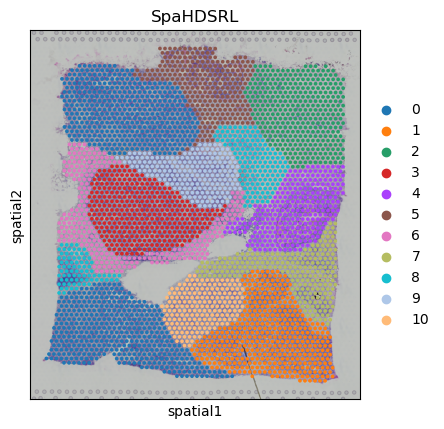

In [16]:
cats_sorted = sorted(
    adata_new.obs["Cluster_SpaHDSRL"].astype(str).unique(),
    key=lambda x: int(x)
)

adata_new.obs["Cluster_SpaHDSRL"] = pd.Categorical(
    adata_new.obs["Cluster_SpaHDSRL"].astype(str),
    categories=cats_sorted,
    ordered=True
)

sc.pl.spatial(
    adata_new,
    color=["Cluster_SpaHDSRL"],
    title='SpaHDSRL',
    spot_size=200
)

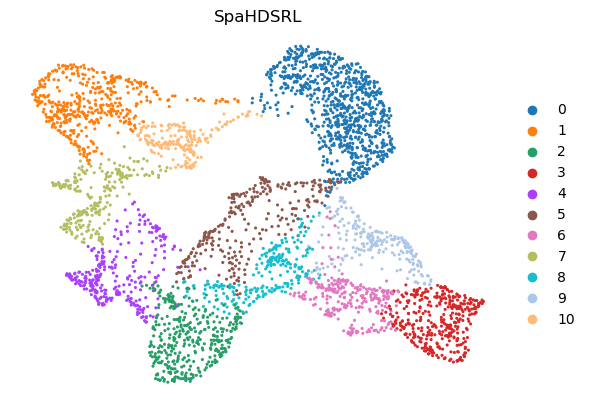

In [17]:
embedding_adata = sc.AnnData(df_embedding.copy())

sc.pp.neighbors(embedding_adata, n_neighbors=50)
sc.tl.umap(embedding_adata)

embedding_adata.obs["Cluster_SpaHDSRL"] = adata_new.obs["Cluster_SpaHDSRL"].values
embedding_adata.obs["fine_annot_type"] = adata.obs["fine_annot_type"].values
embedding_adata.obs["annot_type"] = adata.obs["annot_type"].values

sc.pl.umap(
    embedding_adata,
    color=["Cluster_SpaHDSRL"],
    size=20,
    frameon=False,
    title="SpaHDSRL",
    wspace=0.35
)